In [1]:
import numpy as np
import random
import pandas as pd
import numpy_financial as npf

import os
import psycopg2
import psycopg2.extras as ext
import datetime

In [2]:
''''
chave_prob = {1 : 0.015,
             2:  0.010,
             3:  0.008,
             4:  0.006,
             5:  0.002,
             6:  0.0000}
'''''
chave_prob = {1 : 1.50,
              2:  1.00,
              3:  0.90,
              4:  0.80,
              5:  0.60,
              6:  0.40}   
    
chave_valr = {1 : 1.00,
             2:  1.50,
             3:  2.00,
             4:  3.00,
             5:  3.50,
             6:  4.00}

In [3]:
#[0.419, 0.156, 0.167, 0.146, 0.072, 0.041]
#[1/6, 1/6, 1/6, 1/6, 1/6, 1/6]

class cliente:
    def __init__(self, codigo):
        self.codigo = codigo
 #       self.inad = max(0.02 + np.random.normal(0., 0.005),0.003)
        self.porte = int(np.where(np.random.multinomial(1, [0.419, 0.156, 0.167, 0.146, 0.072, 0.041], size=1) == 1)[1][0] + 1)
        self.inad = max(0.03 + np.random.normal(0., 0.005),0.0003) * chave_prob[self.porte]
        self.mtlp = chave_valr[self.porte]

## Simula base de clientes

In [4]:
clientes = []

for i in range(50000):
    clientes.append(cliente(str(i).zfill(7)))

In [5]:
chave_mdld_rec = {1 : 1.000,
                  2:  1.000,
                  3:  0.900,
                  4:  0.700}

chave_atraso_rec = {1: 360,
                    2: 330,
                    3: 180,
                    4: 120}

chave_mdld_valor = {1 : 4,
                    2:  2,
                    3:  5,
                    4:  10}

chave_prazo =      {1 : 0,
                    2:  0,
                    3:  0,
                    4:  5}

chave_prt_inad =      {1 : 4.50,
                       2:  3.00,
                       3:  2.00,
                       4:  1.00}

(array([201., 414., 230., 101.,  37.,   6.,   5.,   1.,   2.,   3.]),
 array([  430.52896042,  1910.67605502,  3390.82314961,  4870.97024421,
         6351.11733881,  7831.26443341,  9311.411528  , 10791.5586226 ,
        12271.7057172 , 13751.8528118 , 15231.99990639]),
 <BarContainer object of 10 artists>)

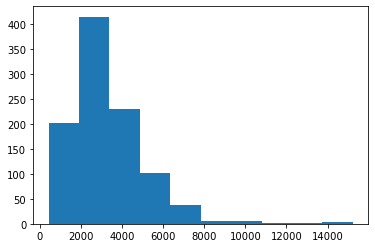

In [6]:
import matplotlib.pyplot as plt 

plt.hist(np.random.lognormal(8., 0.5, size=1000))

In [7]:
#[0.147, 0.779, 0.050, 0.024]
#[1/4, 1/4, 1/4, 1/4]

class operacao:
    def __init__(self, contrato, ref,  mes, dia):
        self.ref = ref
        self.cliente = random.sample(clientes, 1)[0]
        self.modalidade = int(np.where(np.random.multinomial(1, [0.137, 0.757, 0.070, 0.036], size=1) == 1)[1][0] + 1)
        self.valor = (np.random.lognormal(8., 0.5, size=None)) * chave_mdld_valor[self.modalidade] * self.cliente.mtlp
        self.mtpl_inad = chave_prt_inad[self.modalidade]
        self.p_inad = min(self.cliente.inad * self.mtpl_inad, 0.8)
        self.prazo = int(np.random.uniform(low=1, high=10, size=None)) * 6 * (1 + chave_prazo[self.modalidade])
        self.juros = 0.01
        self.mtpl_rec = chave_mdld_rec[self.modalidade]
        self.parcela = npf.pmt(self.juros, self.prazo, self.valor)
        self.multa = 0
        self.pagamento = 0
        self.contrato = contrato
        self.atraso = 0
        self.mes = mes
        self.dia = dia

### Gerar Operações por dia e agregar na base com o mês

In [8]:
def contrata(mes, ctr_dia, ref):
    
    operacoes = []

    for d in range(1, 31):
        q = np.random.poisson(lam=ctr_dia, size=None)
        
        for i in range(q):
            operacoes.append(operacao(str(mes).zfill(3) + str(d).zfill(2)+(str(i)).zfill(6), ref, mes, d))
            
    return(operacoes)

### Atualização do mês
#### e inclusão de novas contratações

In [9]:
def atualiza_mes(anterior, ctr_dia=50):
    #print(len(anterior))
    atual = []

    for i in range(len(anterior)):

        atual.append(anterior[i])

        dia = 30 - anterior[i].dia
        
        #ajustar atraso para somar 30 dias se menor que 30 dia se não + 30
        
        p_atraso = np.random.binomial(size = None, n = 1, p = min(anterior[i].p_inad, 0.99999))
        if anterior[i].atraso < 30:
            temp_atraso = p_atraso * anterior[i].atraso + p_atraso * dia
        else:
            temp_atraso = p_atraso * anterior[i].atraso + p_atraso * 30
            
        if temp_atraso == 0:
            p = anterior[i].p_inad
        elif temp_atraso < 30:
            p = 0.15 + 0.15 * (temp_atraso - 0)/30
        elif temp_atraso < 60:
            p = 0.30 + 0.20 * (temp_atraso - 30)/30
        elif temp_atraso < 90:    
            p = 0.50 + 0.20 * (temp_atraso - 60)/30
        elif temp_atraso < 120:
            p = 0.75 * chave_mdld_rec[atual[i].modalidade]
        elif temp_atraso < 150:
            p = 0.80 * chave_mdld_rec[atual[i].modalidade]
        elif temp_atraso < 180:
            p = 0.88  * chave_mdld_rec[atual[i].modalidade]
        elif temp_atraso < 270:
            p = 0.92 
        elif temp_atraso < 300:
            p = 0.97 
        elif temp_atraso < 330:
            p = 0.99 
        elif temp_atraso < 360:
            p = 0.995 
        else:
            p = 0.99999

        atual[i].cliente.inad = anterior[i].cliente.inad * (p/anterior[i].p_inad)
        atual[i].p_inad = p
        atual[i].prazo = anterior[i].prazo - 1
        atual[i].ref = anterior[i].ref + 1
        
        atual[i].valor = max((anterior[i].valor) * (1 + anterior[i].juros) + ((anterior[i].parcela - atual[i].multa) * (1 - p_atraso)), 0)  
        
        #if atual[i].modalidade == 4 and anterior[i].atraso > 90 and p_atraso == 0:
        if anterior[i].atraso > chave_atraso_rec[atual[i].modalidade] and p_atraso == 0:
                    atual[i].pagamento = atual[i].valor
                    atual[i].valor = 0
                    atual[i].prazo = 0
        else:
            atual[i].pagamento = (-anterior[i].parcela + anterior[i].multa) * (1 - p_atraso)
            
        atual[i].atraso = temp_atraso

        atual[i].multa = - (anterior[i].parcela * p_atraso * (1 + anterior[i].juros)) + (anterior[i].multa * p_atraso)
        
        
    atual.extend(contrata(anterior[i].mes + 1, ctr_dia, anterior[i].ref))
    
    return(atual)

        ## Incluir probabilidade de inadimplência em 1 mês ok
        ## atualizar dias de atraso ok
        ## utilizar probabilidades de recuperação e inadimplência do System Dynamics ok
        
        
        ## atualizar mes de referencia ok
        ## atualizar prazo ok
        ## atualizar liquidação ok
        ## exportar cada nova tabela ok
        ## criar loop ok
        ## atualizar probabilidades na base de clientes ok

## Bases geradas

In [ ]:
nmes = 200
choque = []
ctr_dia = 10
    
now = datetime.datetime.now()
print ("Início do processamento base 0 :", now.strftime("%Y-%m-%d %H:%M:%S"))
    
base0 = contrata(0, ctr_dia, 0)
linhas = len(base0)

conn = psycopg2.connect("host=localhost port=5432 dbname=Simulacred user=postgres password=12345678")
cur = conn.cursor(cursor_factory = ext.DictCursor)

for n in range(linhas):
    log = []
    sql = "INSERT INTO jpcosta.operacoes( ref, cliente, porte, contrato, modalidade, prazo, valor, mes, dia, prob_opr, prob_cli, atraso, pgto ) VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s) RETURNING *;"
    values = [base0[n].ref , base0[n].cliente.codigo, base0[n].cliente.porte, base0[n].contrato, base0[n].modalidade, base0[n].prazo, base0[n].valor, base0[n].mes, base0[n].dia, base0[n].p_inad, base0[n].cliente.inad, base0[n].atraso, base0[n].pagamento]
    cur.execute(sql, values)
    conn.commit()
    results = cur.fetchall()
cur.close()
conn.close()


now = datetime.datetime.now()

print ("Fim do processamento base 0    :", now.strftime("%Y-%m-%d %H:%M:%S"))

for i in range(nmes):
    now = datetime.datetime.now()
    print ("Início do processamento base", str(i + 1), ":", now.strftime("%Y-%m-%d %H:%M:%S"))
    exec("base" + str(i+1) + " = atualiza_mes(" + "base" + str(i) + ", "+ str(ctr_dia) + ")",)
    exec("linhas = len(base" + str(i + 1) + ")")      

    conn = psycopg2.connect("host=localhost port=5432 dbname=Simulacred user=postgres password=12345678")
    cur = conn.cursor(cursor_factory = ext.DictCursor)
    exec("linhas = len(base" + str(i + 1) + ")")
    
    for n in range(linhas):
        exec("saldo = base" + str(i + 1) + "[n].valor")
        exec("dias = base" + str(i + 1) + "[n].atraso")
        exec("prazo = base" + str(i + 1) + "[n].prazo")
        if saldo < 1.0 and dias == 0 and prazo < 0:
            None
        else:
            sql = "INSERT INTO jpcosta.operacoes( ref, cliente, porte, contrato, modalidade, prazo, valor, mes, dia, prob_opr, prob_cli, atraso, pgto ) VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s) RETURNING *;"
            exec("values = [base"+ str(i+1) + "[n].ref " + ", base"+ str(i+1) + "[n].cliente.codigo" + ", base"+ str(i+1) + "[n].cliente.porte" + ", base"+ str(i+1) + "[n].contrato" + ", base"+ str(i+1) + "[n].modalidade" +  ", base"+ str(i+1) + "[n].prazo" + ", base"+ str(i+1) + "[n].valor" + ", base"+ str(i+1) + "[n].mes" +
                 ", base"+ str(i+1) + "[n].dia" + ", base"+ str(i+1) + "[n].p_inad" + ", base"+ str(i+1) + "[n].cliente.inad" + ", base"+ str(i+1) + "[n].atraso" + ", base"+ str(i+1) + "[n].pagamento]", globals(), locals())
            cur.execute(sql, values)
            conn.commit()
            results = cur.fetchall()
    cur.close()
    conn.close()
                
    now = datetime.datetime.now()
    print ("Fim do processamento base", str(i + 1), "   :", now.strftime("%Y-%m-%d %H:%M:%S"))

Início do processamento base 0 : 2021-12-14 13:03:03
Fim do processamento base 0    : 2021-12-14 13:03:04
Início do processamento base 1 : 2021-12-14 13:03:04
Fim do processamento base 1    : 2021-12-14 13:03:07
Início do processamento base 2 : 2021-12-14 13:03:07
Fim do processamento base 2    : 2021-12-14 13:03:10
Início do processamento base 3 : 2021-12-14 13:03:10
Fim do processamento base 3    : 2021-12-14 13:03:14
Início do processamento base 4 : 2021-12-14 13:03:14
Fim do processamento base 4    : 2021-12-14 13:03:20
Início do processamento base 5 : 2021-12-14 13:03:20
Fim do processamento base 5    : 2021-12-14 13:03:26
Início do processamento base 6 : 2021-12-14 13:03:26
Fim do processamento base 6    : 2021-12-14 13:03:34
Início do processamento base 7 : 2021-12-14 13:03:34
Fim do processamento base 7    : 2021-12-14 13:03:43
Início do processamento base 8 : 2021-12-14 13:03:43
Fim do processamento base 8    : 2021-12-14 13:03:52
Início do processamento base 9 : 2021-12-14 13

In [ ]:
cur.close()
conn.close()